# How candidate ranking works

We follow one molecule through `rank_candidates.py`:

0. Pick a molecule and predict its fingerprint (2048 bit probabilities) from its spectra.
1. **Candidates**: every structure of the pool (train + COCONUT) whose exact mass is within 10 ppm of the molecule's neutral mass.
2. **Score**: how well each candidate's true fingerprint agrees with the predicted probabilities.
3. **Rank**: sort by score, keep one row per inchikey14, and look at the top 25.

In [26]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import Draw

sys.path.insert(0, "../src")  # the fingerprints_MLP modules
from build_spectrum_arrays import TRAIN_PATH
from metadata_features import neutral_mass_expression
from morgan_generator import fingerprint
from predict import load_model, predict_probabilities, spectra_to_arrays
from rank_candidates import PPM_TOLERANCE, CandidateLibrary, likelihood_scores
from train_MLP import LIBRARY_DIR, MODEL_DIR, SEED, split_spectra_by_molecule

MODEL_NAME = "mlp.pt"
EXAMPLE_SEED = None # 1
TOP_K = 25

## 0. A molecule the model never saw

The training scripts all split the molecules with `split_spectra_by_molecule` and `SEED`: the validation molecules
are removed from training in every library. We redo that split, pick one validation molecule, and check that none of
its spectra are among the training spectra. We keep its enveda-180 spectra of one adduct, like a test `molecule_id`.

This holds for the models trained with this split after `library/molecules.parquet` was last written
(`mlp_all_libraries`, `mlp_negatives`, `mlp_resampled`, `mlp_dreams`). `mlp.pt` is older than that file, so its
split may differ.

In [27]:
spectrum_info = pl.scan_parquet(TRAIN_PATH).select("ingest_lib", "inchikey14").collect()
fp_index = np.load(LIBRARY_DIR / "spectrum_arrays.npz")["fp_index"]

# same seed and same split as the training scripts
rng = np.random.default_rng(SEED)
train_indices, validation_indices = split_spectra_by_molecule(fp_index, spectrum_info["ingest_lib"], rng)
training_inchikey14 = spectrum_info[train_indices]["inchikey14"].unique()
validation_inchikey14 = spectrum_info[validation_indices]["inchikey14"].unique().sort()

true_inchikey14 = validation_inchikey14.sample(1, seed=EXAMPLE_SEED)[0]
assert true_inchikey14 not in training_inchikey14, f"{true_inchikey14} has spectra in the training set"
print(f"{len(validation_inchikey14)} validation molecules, example: {true_inchikey14} (no training spectrum)")

9189 validation molecules, example: QWVNHSNOQUNSHS (no training spectrum)


In [28]:
all_spectra = pl.scan_parquet(TRAIN_PATH).filter(
    (pl.col("inchikey14") == true_inchikey14) & (pl.col("ingest_lib") == "enveda-180")
).collect()

adduct = all_spectra["adduct"].sort()[0]
spectra = all_spectra.filter(pl.col("adduct") == adduct)
true_smiles = spectra["normalized_smiles"][0]

print(true_smiles)
spectra.select("adduct", "precursor_mz", "collision_energy_ev", "num_peaks")

CC(=O)NCCNC(=O)CNC1CCCN(c2ccc(C)nn2)C1


adduct,precursor_mz,collision_energy_ev,num_peaks
str,f64,list[f64],i64
"""[M+CH2O2-H]-""",379.2096,[40.0],18


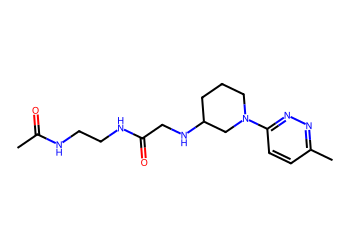

In [29]:
Draw.MolToImage(Chem.MolFromSmiles(true_smiles), size=(350, 250))

### Predicted fingerprint

One prediction per spectrum, averaged over the collision energies.
In the plot, a good prediction puts the true bits (orange) high and the other bits (blue) near 0.

In [30]:
model = load_model(MODEL_DIR / MODEL_NAME)
peak_bins, peak_intensities, metadata = spectra_to_arrays(spectra)
probabilities = predict_probabilities(model, peak_bins, peak_intensities, metadata).mean(axis=0)

true_bits = fingerprint(true_smiles)
print(f"{true_bits.sum()} bits on in the true fingerprint")
print(f"mean probability of the true bits: {probabilities[true_bits == 1].mean():.2f}, of the others: {probabilities[true_bits == 0].mean():.3f}")

49 bits on in the true fingerprint
mean probability of the true bits: 0.28, of the others: 0.019


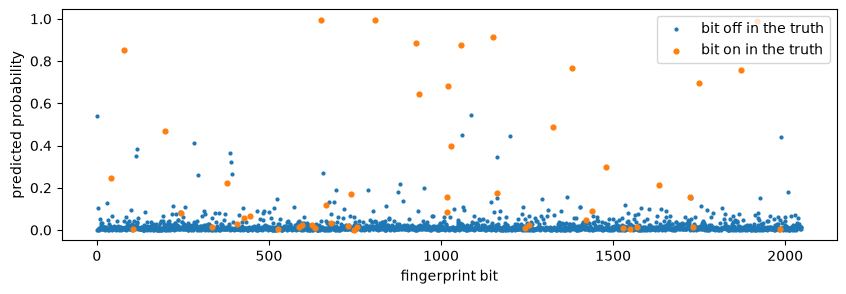

In [31]:
bit_index = np.arange(len(probabilities))
is_on = true_bits == 1

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(bit_index[~is_on], probabilities[~is_on], s=4, color="tab:blue", label="bit off in the truth")
ax.scatter(bit_index[is_on], probabilities[is_on], s=12, color="tab:orange", label="bit on in the truth")
ax.set_xlabel("fingerprint bit")
ax.set_ylabel("predicted probability")
ax.legend()
plt.show()

## 1. Candidates: the mass window

The pool is sorted by exact mass, so the structures within 10 ppm of the neutral mass are one contiguous block
of rows (`CandidateLibrary.candidates_in_mass_window`).

In [32]:
pool_columns = ["normalized_smiles", "inchikey14", "exact_mass"]
train_molecules = pl.read_parquet(LIBRARY_DIR / "molecules.parquet").select(pool_columns)
coconut_molecules = pl.read_parquet(LIBRARY_DIR / "coconut_molecules.parquet").select(pool_columns)
train_fingerprints = np.load(LIBRARY_DIR / "morgan_fingerprints.npy")
coconut_fingerprints = np.load(LIBRARY_DIR / "coconut_fingerprints.npy")

pool = CandidateLibrary(
    pl.concat([train_molecules, coconut_molecules]),
    np.concatenate([train_fingerprints, coconut_fingerprints]),
)
print(f"pool: {pool.molecules.height:,} structures")

pool: 757,252 structures


In [33]:
neutral_mass = spectra.select(neutral_mass_expression()).to_series().mean()
positions = pool.candidates_in_mass_window(neutral_mass)
candidates = pool.molecules[positions]

print(f"neutral mass {neutral_mass:.4f} Da, window ±{PPM_TOLERANCE:g} ppm = ±{neutral_mass * PPM_TOLERANCE * 1e-6:.4f} Da")
print(f"{candidates.height} candidate rows, {candidates['inchikey14'].n_unique()} distinct inchikey14")
print(f"truth among the candidates: {true_inchikey14 in candidates['inchikey14']}")

neutral mass 334.2114 Da, window ±10 ppm = ±0.0033 Da
596 candidate rows, 565 distinct inchikey14
truth among the candidates: True


## 2. Score each candidate

`likelihood_scores`: log-likelihood of the candidate's fingerprint under the predicted probabilities.
Up to a constant shared by all candidates, it is the sum of the log-odds `log(p / (1 - p))` of the bits the candidate has on:
a bit the model believes in adds to the score, a bit it rules out costs a lot.

In [34]:
candidate_bits = np.unpackbits(pool.packed_fingerprints[positions], axis=1, count=len(probabilities))
candidate_bits = candidate_bits.astype(np.float32)
scores = likelihood_scores(probabilities, candidate_bits)

is_truth = (candidates["inchikey14"] == true_inchikey14).to_numpy()
print(f"score of the truth: {scores[is_truth].max():.1f}, best score: {scores.max():.1f}, median: {np.median(scores):.1f}")

score of the truth: -86.3, best score: -33.2, median: -125.1


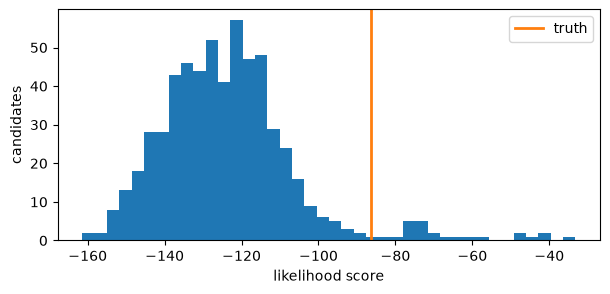

In [35]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores, bins=40, color="tab:blue")
ax.axvline(scores[is_truth].max(), color="tab:orange", linewidth=2, label="truth")
ax.set_xlabel("likelihood score")
ax.set_ylabel("candidates")
ax.legend()
plt.show()

In [36]:
## mean entropy of the bits predicted by mLP

entropy = -probabilities * np.log2(probabilities + 1e-10) - (1 - probabilities) * np.log2(1 - probabilities + 1e-10)
print(f"mean entropy of the bits: {entropy.mean():.3f} bits")

mean entropy of the bits: 0.119 bits


## 3. Rank and keep the top 25

`CandidateLibrary.rank` does steps 1 and 2, sorts by score and keeps the best row of each inchikey14
(the metric compares inchikey14, so a stereoisomer of a candidate would only waste a slot).

truth at rank 22 of 565: reciprocal rank 0.05


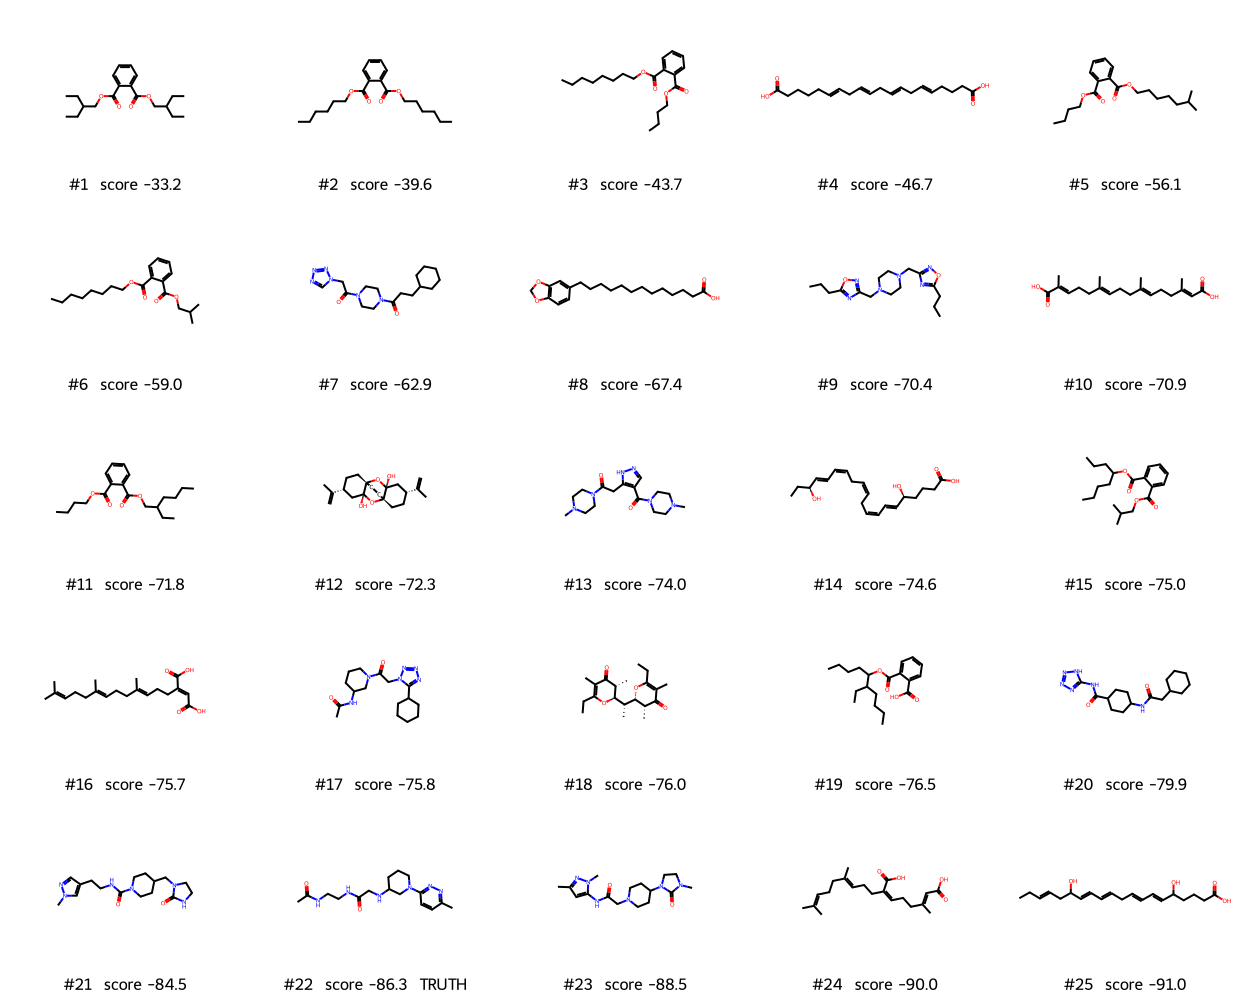

In [37]:
ranking = pool.rank(probabilities, neutral_mass, scorer="likelihood")
ranking = ranking.with_row_index("rank", offset=1)
top = ranking.head(TOP_K)

true_position = ranking["inchikey14"].index_of(true_inchikey14)
if true_position is None:
    print("the truth is not a candidate")
else:
    print(f"truth at rank {true_position + 1} of {ranking.height}: reciprocal rank {1 / (true_position + 1):.2f}")
# top

molecules = [Chem.MolFromSmiles(smiles) for smiles in top["normalized_smiles"]]
legends = []
for rank, inchikey14, score in top.select("rank", "inchikey14", "score").iter_rows():
    label = f"#{rank}  score {score:.1f}"
    if inchikey14 == true_inchikey14:
        label = label + "  TRUTH"
    legends.append(label)

Draw.MolsToGridImage(molecules, molsPerRow=5, subImgSize=(250, 200), legends=legends)